In [113]:
import torch
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Tokenizer, GPT2LMHeadModel

In [114]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 128
BATCH_SIZE = 4
EPOCHS = 10
LR = 4e-5

STYLE_PROMPT = (
    "You are a precise and helpful assistant. "
    "Answer clearly and directly. Avoid repetition and meaningless text. "
    "Be informative but concise."
)

sns.set_theme(style="whitegrid")

In [115]:
tok = GPT2Tokenizer.from_pretrained("gpt2")
tok.add_special_tokens({
    "additional_special_tokens": ["<|user|>", "<|assistant|>", "<|style|>"]
})
tok.pad_token = tok.eos_token

c:\Program Files\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [116]:
samples = [
    # ---- Greetings / Basics ----
    {"user": "Hello", "assistant": "Hi. How can I help?"},
    {"user": "Hi", "assistant": "Hello. What do you need?"},
    {"user": "Who are you?", "assistant": "I am an AI assistant trained to answer questions and help with tasks."},
    {"user": "What can you do?", "assistant": "I can explain concepts, write code, solve problems, and answer questions."},

    # ---- Simple Q&A ----
    {"user": "What is AI?", "assistant": "Artificial Intelligence is the field of building systems that can perform tasks requiring human-like intelligence."},
    {"user": "What is machine learning?", "assistant": "Machine learning is a subset of AI where models learn patterns from data instead of being explicitly programmed."},
    {"user": "Difference between AI and ML?", "assistant": "AI is the broader concept of intelligent systems. Machine learning is a method used within AI."},

    # ---- GAN / Deep Learning ----
    {"user": "What is GAN?", "assistant": "A GAN consists of a generator and a discriminator trained in opposition to produce realistic data."},
    {"user": "What does the generator do?", "assistant": "The generator creates synthetic data from noise to mimic real data."},
    {"user": "What does the discriminator do?", "assistant": "The discriminator distinguishes between real and generated data."},
    {"user": "Why are GANs hard to train?", "assistant": "They require a balance between generator and discriminator; instability can cause collapse or divergence."},

    # ---- Overfitting / ML concepts ----
    {"user": "Explain overfitting", "assistant": "Overfitting occurs when a model memorizes training data and fails to generalize to new data."},
    {"user": "How to prevent overfitting?", "assistant": "Use regularization, dropout, more data, or early stopping."},
    {"user": "What is underfitting?", "assistant": "Underfitting happens when a model is too simple to capture patterns in the data."},

    # ---- Programming ----
    {"user": "What is Python?", "assistant": "Python is a high-level programming language known for readability and versatility."},
    {"user": "Write a loop in Python", "assistant": "Example: for i in range(5): print(i)"},
    {"user": "What is a function?", "assistant": "A function is a reusable block of code that performs a specific task."},
    {"user": "Explain recursion", "assistant": "Recursion is when a function calls itself to solve smaller instances of a problem."},

    # ---- Debugging ----
    {"user": "My code is not working", "assistant": "Provide the error message and code snippet. I will help identify the issue."},
    {"user": "What is a syntax error?", "assistant": "A syntax error occurs when code violates the language rules."},

    # ---- Math ----
    {"user": "What is 2+2?", "assistant": "4"},
    {"user": "What is derivative?", "assistant": "A derivative measures how a function changes with respect to its input."},
    {"user": "What is integral?", "assistant": "An integral represents accumulation, such as area under a curve."},

    # ---- Structured explanations ----
    {"user": "Explain neural networks simply", "assistant": "Neural networks are models made of layers of nodes that learn patterns by adjusting weights."},
    {"user": "Explain CNN", "assistant": "A Convolutional Neural Network processes images using filters to detect patterns like edges and textures."},
    {"user": "Explain RNN", "assistant": "A Recurrent Neural Network processes sequences by maintaining a memory of previous inputs."},

    # ---- Real-world reasoning ----
    {"user": "Why is the sky blue?", "assistant": "The sky appears blue due to scattering of shorter wavelengths of sunlight in the atmosphere."},
    {"user": "Why do we sleep?", "assistant": "Sleep helps restore the body, consolidate memory, and maintain brain function."},

    # ---- Instruction following ----
    {"user": "Summarize GAN in one sentence", "assistant": "A GAN trains a generator and discriminator in competition to produce realistic data."},
    {"user": "Explain overfitting in one line", "assistant": "Overfitting is when a model learns noise instead of general patterns."},

    # ---- Tone control ----
    {"user": "Explain AI briefly", "assistant": "AI is the field of building systems that can perform intelligent tasks."},
    {"user": "Explain AI in detail", "assistant": "AI involves algorithms and models that simulate human intelligence, including learning, reasoning, and perception."},

    # ---- Refusal / boundaries ----
    {"user": "Give me illegal hacking steps", "assistant": "I cannot assist with illegal activities."},
    {"user": "How to cheat in exams?", "assistant": "I cannot help with that. I can help you study effectively instead."},

    # ---- Multi-step reasoning ----
    {"user": "How to learn programming?", "assistant": "Start with basics, practice consistently, build projects, and review errors."},
    {"user": "Steps to build a model?", "assistant": "Collect data, preprocess it, choose a model, train, evaluate, and improve."},

    # ---- Code explanation ----
    {"user": "Explain this: for i in range(3): print(i)", "assistant": "This loop prints numbers from 0 to 2."},

    # ---- Edge cases ----
    {"user": "", "assistant": "Please provide a question."},
    {"user": "???", "assistant": "Clarify your question so I can help."}
]

In [117]:
class ChatDS(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        u = self.pairs[idx]["user"].strip()
        a = self.pairs[idx]["assistant"].strip()

        prompt = (
            f"<|style|>{STYLE_PROMPT}\n"
            f"<|user|> {u}\n"
            f"<|assistant|>"
        )

        full_text = prompt + " " + a + tok.eos_token

        enc_full = tok(
            full_text,
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt"
        )

        enc_prompt = tok(
            prompt,
            truncation=True,
            max_length=MAX_LEN,
            add_special_tokens=False,
            return_tensors="pt"
        )

        input_ids = enc_full["input_ids"].squeeze(0)
        attention_mask = enc_full["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # mask padding
        labels[attention_mask == 0] = -100

        # mask prompt (user part)
        prompt_len = enc_prompt["input_ids"].shape[1]
        labels[:prompt_len] = -100

        # CRITICAL: ensure at least one valid token exists
        if (labels != -100).sum() == 0:
            labels[-1] = input_ids[-1]

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [118]:
loader = DataLoader(ChatDS(samples), batch_size=BATCH_SIZE, shuffle=True)

In [119]:
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.resize_token_embeddings(len(tok))
model.config.pad_token_id = tok.eos_token_id
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

In [120]:
def train():
    losses = []
    perplexities = []

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0

        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            out = model(**batch)
            loss = out.loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        ppl = math.exp(avg_loss)

        losses.append(avg_loss)
        perplexities.append(ppl)

        print(f"Epoch {epoch+1}/{EPOCHS} | Loss={avg_loss:.4f} | PPL={ppl:.2f}")

    return losses, perplexities

losses, perplexities = train()

Epoch 1/10 | Loss=28.3497 | PPL=2051621995414.97
Epoch 2/10 | Loss=5.0437 | PPL=155.04
Epoch 3/10 | Loss=3.5090 | PPL=33.42
Epoch 4/10 | Loss=3.2769 | PPL=26.49
Epoch 5/10 | Loss=2.4745 | PPL=11.88
Epoch 6/10 | Loss=2.0432 | PPL=7.72
Epoch 7/10 | Loss=1.7159 | PPL=5.56
Epoch 8/10 | Loss=1.4190 | PPL=4.13
Epoch 9/10 | Loss=1.1294 | PPL=3.09
Epoch 10/10 | Loss=0.8603 | PPL=2.36


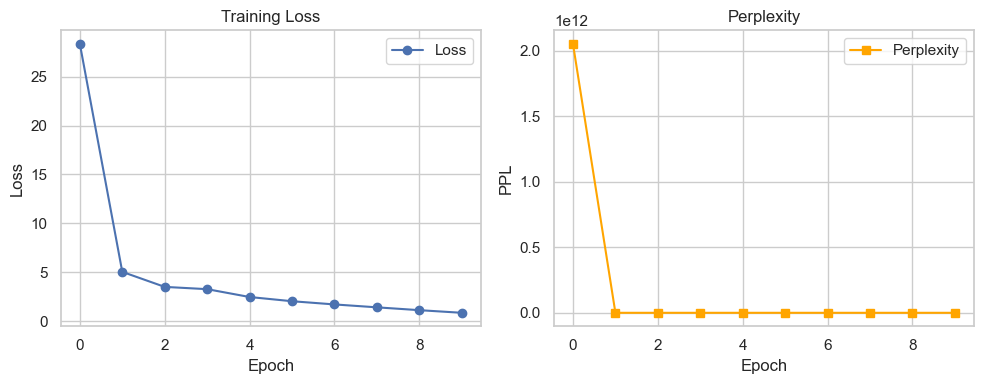

In [121]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss", marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(perplexities, label="Perplexity", color="orange", marker="s")
plt.title("Perplexity")
plt.xlabel("Epoch")
plt.ylabel("PPL")
plt.legend()

plt.tight_layout()
plt.show()

In [122]:
def generate_reply(user_text, temperature=0.7):
    model.eval()

    prompt = (
        f"<|style|>{STYLE_PROMPT}\n"
        f"<|user|> {user_text.strip()}\n"
        f"<|assistant|>"
    )

    inp = tok(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        out = model.generate(
            **inp,
            max_new_tokens=80,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            top_k=50,
            repetition_penalty=1.3,          # ↑ critical
            no_repeat_ngram_size=3,          # ↑ critical
            pad_token_id=tok.eos_token_id,
            eos_token_id=tok.eos_token_id
        )

    text = tok.decode(out[0], skip_special_tokens=False)

    if "<|assistant|>" in text:
        text = text.split("<|assistant|>")[-1]
    if "<|user|>" in text:
        text = text.split("<|user|>")[0]

    return text.strip()

In [123]:
print("\n--- TEST OUTPUT ---")
for t in [0.5, 0.7, 1.0, 1.2]:
    print(f"\nTemperature: {t}")
    print(generate_reply("Explain GAN: ", temperature=t))


--- TEST OUTPUT ---

Temperature: 0.5
AGAN trains an AI to solve problems in competition with respect instead of requiring specific inputs from the model itself<|endoftext|>

Temperature: 0.7
AGAN trains networks by maintaining discriminator patterns between inputs, instead of requiring weights to capture errors in the data itself<|endoftext|>

Temperature: 1.0
A generator gathers data from sensors, models or AI to improve processes; the more noise in nature is reduced with smaller amounts of input(s)<|endoftext|>

Temperature: 1.2
An AI helps model tasks requiring intelligent systems instead of relying on memory or programmed language learning<|endoftext|>


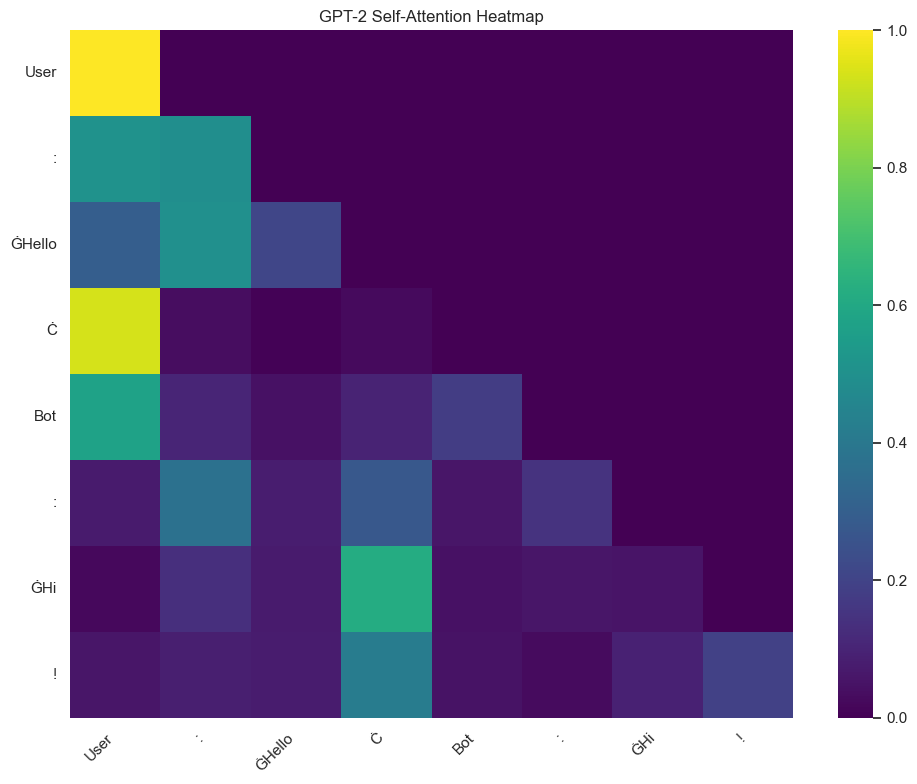

In [124]:
def show_gpt_attention(text):
    viz_model = GPT2LMHeadModel.from_pretrained("gpt2", output_attentions=True).to(DEVICE)
    viz_model.eval()

    inputs = tok(text, return_tensors="pt").to(DEVICE)
    tokens = tok.convert_ids_to_tokens(inputs["input_ids"][0])

    with torch.no_grad():
        out = viz_model(**inputs)

    # last layer, first head
    att = out.attentions[-1][0][0].detach().cpu().numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title("GPT-2 Self-Attention Heatmap")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

show_gpt_attention("User: Hello\nBot: Hi!")